# Trump Sentiment Trading Strategy Backtesting Analysis

This notebook runs and analyzes the quantitative performance of the Trump sentiment-based trading strategy.

### Strategy Parameters:
- **Initial Capital**: $10,000.00
- **Transaction Costs**: 5.0 basis points (0.05%) per trade
- **Sentiment Entry Threshold**: $\pm 0.05$
- **Holding Horizons**: 1-hour (`1h`) and 1-day (`1d`)
- **Trading Modes**:
  - **Directional**: Long on positive sentiment, Short on negative sentiment.
  - **Reversal**: Short on positive sentiment, Long on negative sentiment.

In [1]:
import os
import subprocess
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [14, 7]
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'sans-serif'

## Compile C++ Backtester Engine

We compile the C++ backtester source code in `src/cpp/backtester.cpp` to ensure `backtester.exe` is up to date.

In [2]:
cpp_dir = os.path.abspath("../cpp")
compile_script = os.path.join(cpp_dir, "compile.bat")

print("Compiling C++ backtesting engine...")
try:
    result = subprocess.run(
        [compile_script],
        cwd=cpp_dir,
        capture_output=True,
        text=True,
        shell=True
    )
    if result.returncode != 0:
        print("Compilation failed! Errors:")
        print(result.stderr)
    else:
        print("Compilation successful! Executables updated.")
        print(result.stdout)
except Exception as e:
    print(f"Error running compilation: {e}")

Compiling C++ backtesting engine...


Compilation successful! Executables updated.
Compiling event_study_engine.cpp...
Compiling backtester.cpp...
Compilation successful! Executables created in src/cpp/



## Backtest Execution Wrapper

We define a helper function to run the compiled C++ backtester for a specific configuration and parse the output metrics.

In [3]:
def run_backtest(asset, topic, horizon, reversal=False):
    # Path to the executable and project root
    project_root = os.path.abspath("../..")
    exe_path = os.path.abspath(os.path.join(project_root, "src", "cpp", "backtester.exe"))
    
    # Build command line arguments
    cmd = [
        exe_path,
        "--asset", asset,
        "--topic", topic,
        "--horizon", horizon
    ]
    if reversal:
        cmd.append("--reversal")
        
    # Run from project root
    result = subprocess.run(
        cmd,
        cwd=project_root,
        capture_output=True,
        text=True
    )
    
    if result.returncode != 0:
        print(f"Error executing backtester for {asset} {topic} {horizon}:")
        print(result.stderr)
        return None
        
    stdout = result.stdout
    
    # Parse console output using regular expressions
    def extract(pattern, text, default=np.nan, transform=float):
        match = re.search(pattern, text)
        if match:
            try:
                return transform(match.group(1))
            except ValueError:
                return match.group(1)
        return default
        
    metrics = {
        "Asset": asset,
        "Topic": topic,
        "Horizon": horizon,
        "Mode": "Reversal" if reversal else "Directional"
    }
    
    metrics["Total Trades"] = extract(r"Total Trades:\s*(\d+)", stdout, default=0, transform=int)
    
    if metrics["Total Trades"] > 0:
        metrics["Winning Trades"] = extract(r"Winning Trades:\s*(\d+)", stdout, transform=int)
        metrics["Losing Trades"] = extract(r"Losing Trades:\s*(\d+)", stdout, transform=int)
        metrics["Win Rate (%)"] = extract(r"Win Rate:\s*([\d\.]+)%", stdout)
        metrics["Initial Capital ($)"] = extract(r"Initial Capital:\s*\$([\d\.]+)", stdout)
        metrics["Final Equity ($)"] = extract(r"Final Equity:\s*\$([\d\.]+)", stdout)
        metrics["Profit/Loss ($)"] = extract(r"Total Profit/Loss:\s*\$([-\d\.]+)", stdout)
        metrics["Profit/Loss (%)"] = extract(r"Total Profit/Loss:\s*\$[-\d\.]+\s*\(([-\d\.]+)%\)", stdout)
        metrics["Annualized Return (%)"] = extract(r"Annualized Return:\s*([-\d\.]+)%", stdout)
        metrics["Max Drawdown (%)"] = extract(r"Max Drawdown:\s*([\d\.]+)%", stdout)
        metrics["Sharpe Ratio"] = extract(r"Sharpe Ratio:\s*([-\d\.]+)", stdout)
        metrics["Trades/Year"] = extract(r"Trades/Year \(Avg\):\s*([\d\.]+)", stdout)
    else:
        metrics["Winning Trades"] = 0
        metrics["Losing Trades"] = 0
        metrics["Win Rate (%)"] = 0.0
        metrics["Initial Capital ($)"] = 10000.00
        metrics["Final Equity ($)"] = 10000.00
        metrics["Profit/Loss ($)"] = 0.00
        metrics["Profit/Loss (%)"] = 0.00
        metrics["Annualized Return (%)"] = 0.00
        metrics["Max Drawdown (%)"] = 0.00
        metrics["Sharpe Ratio"] = 0.00
        metrics["Trades/Year"] = 0.0
        
    # Generate output trade log path
    reversal_suffix = "_reversal" if reversal else ""
    clean_topic = topic.replace("/", "_")
    csv_filename = f"backtest_trades_{asset}_{clean_topic}_{horizon}{reversal_suffix}.csv"
    csv_path = os.path.join(project_root, "results", "backtesting-results", csv_filename)
    metrics["CSV Path"] = csv_path
    
    return metrics

## Run Backtests Across All Configurations

We run the strategy for all the target assets, intervals, and topics requested. We evaluate both the default directional mode and the reversal mode for each configuration.

In [4]:
configurations = [
    # CL Technology 1-hr & 1-day
    {"asset": "CL", "topic": "Technology", "horizon": "1h"},
    {"asset": "CL", "topic": "Technology", "horizon": "1d"},
    
    # ES all topics except Technology 1-day
    {"asset": "ES", "topic": "China", "horizon": "1d"},
    {"asset": "ES", "topic": "Federal politics", "horizon": "1d"},
    {"asset": "ES", "topic": "Iran war/Oil", "horizon": "1d"},
    {"asset": "ES", "topic": "National security/Immigration", "horizon": "1d"},
    {"asset": "ES", "topic": "Tariffs", "horizon": "1d"},
    
    # YM China 1-hr & 1-day
    {"asset": "YM", "topic": "China", "horizon": "1h"},
    {"asset": "YM", "topic": "China", "horizon": "1d"},
    
    # YM Federal politics 1-day
    {"asset": "YM", "topic": "Federal politics", "horizon": "1d"},
    
    # I_NDX Federal politics 1-day
    {"asset": "I_NDX", "topic": "Federal politics", "horizon": "1d"}
]

results = []
print("Running backtests...")
for config in configurations:
    for reversal in [False, True]:
        metrics = run_backtest(
            asset=config["asset"],
            topic=config["topic"],
            horizon=config["horizon"],
            reversal=reversal
        )
        if metrics:
            results.append(metrics)

df_results = pd.DataFrame(results)
print(f"Successfully completed {len(df_results)} backtest runs.")

Running backtests...


Successfully completed 22 backtest runs.


## Performance Summary Table

We compile all results into a sorted table to identify the best-performing strategy settings. The table is sorted by **Sharpe Ratio** descending.

In [5]:
# Filter columns for summary presentation
df_summary = df_results.drop(columns=["CSV Path", "Initial Capital ($)"])
df_summary = df_summary.sort_values(by="Sharpe Ratio", ascending=False).reset_index(drop=True)

# Apply background gradients to the dataframe view
styled_summary = df_summary.style \
    .background_gradient(subset=["Sharpe Ratio"], cmap="RdYlGn", vmin=-2.0, vmax=2.0) \
    .background_gradient(subset=["Profit/Loss (%)"], cmap="RdYlGn", vmin=-15.0, vmax=15.0) \
    .background_gradient(subset=["Max Drawdown (%)"], cmap="Reds", vmin=0.0, vmax=20.0) \
    .format({
        "Win Rate (%)": "{:.2f}%",
        "Final Equity ($)": "${:,.2f}",
        "Profit/Loss ($)": "${:+,.2f}",
        "Profit/Loss (%)": "{:+,.2f}%",
        "Annualized Return (%)": "{:.2f}%",
        "Max Drawdown (%)": "{:.2f}%",
        "Sharpe Ratio": "{:.3f}",
        "Trades/Year": "{:.1f}"
    })

display(Markdown("### Strategy Performance"))
styled_summary

### Strategy Performance

,Asset,Topic,Horizon,Mode,Total Trades,Winning Trades,Losing Trades,Win Rate (%),Final Equity ($),Profit/Loss ($),Profit/Loss (%),Annualized Return (%),Max Drawdown (%),Sharpe Ratio,Trades/Year
0,YM,China,1d,Reversal,63,45,18,71.43%,"$11,544.61","$+1,544.61",+15.45%,11.08%,3.24%,1.668,46.1
1,CL,Technology,1h,Directional,61,33,28,54.10%,"$10,487.79",$+487.79,+4.88%,3.58%,2.07%,1.291,45.0
2,ES,China,1d,Reversal,63,40,23,63.49%,"$11,339.95","$+1,339.95",+13.40%,9.63%,4.42%,1.170,46.1
3,CL,Technology,1d,Directional,61,34,27,55.74%,"$11,658.53","$+1,658.53",+16.59%,11.99%,10.49%,1.112,45.0
4,ES,Iran war/Oil,1d,Directional,169,73,96,43.20%,"$11,702.65","$+1,702.65",+17.03%,11.97%,6.26%,0.901,121.5
5,I_NDX,Federal politics,1d,Directional,1961,1059,902,54.00%,"$13,877.40","$+3,877.40",+38.77%,26.06%,80.01%,0.715,1385.7
6,ES,Tariffs,1d,Directional,216,113,103,52.31%,"$10,913.79",$+913.79,+9.14%,6.50%,23.77%,0.412,155.5
7,YM,China,1h,Directional,63,15,48,23.81%,"$9,895.48",$-104.52,-1.05%,-0.77%,3.19%,-0.456,46.1
8,ES,National security/Immigration,1d,Directional,444,212,232,47.75%,"$8,745.03","$-1,254.97",-12.55%,-9.25%,25.26%,-0.581,321.3
9,YM,Federal politics,1d,Reversal,1961,1029,932,52.47%,"$5,580.99","$-4,419.01",-44.19%,-33.78%,72.10%,-0.964,1385.7


In [6]:
import os
import dataframe_image as dfi

# Export directory
results_dir = os.path.abspath("../../results/backtesting-results")
os.makedirs(results_dir, exist_ok=True)

# Export as XLSX
excel_path = os.path.join(results_dir, "backtest_performance_summary.xlsx")
try:
    styled_summary.to_excel(excel_path, engine="openpyxl")
    print(f"Saved Excel to: {excel_path}")
except Exception as e:
    print(f"Excel export failed: {e}")

## Export as PNG
#png_path = os.path.join(results_dir, "backtest_performance_summary.png")
#try:
#    dfi.export(styled_summary, png_path, table_conversion="matplotlib")
#    print(f"Saved PNG to: {png_path}")
#except Exception as e:
#    print(f"PNG export failed: {e}")

Saved Excel to: c:\Users\limli\Documents\Personal Projects\Github\Trump Market Analysis\results\backtesting-results\backtest_performance_summary.xlsx


## Visualize Equity Curves

We load the trade records from the generated CSV logs and plot the equity curves of the **top 5 configurations** to visually evaluate their growth trajectory. The earliest datapoints represent the outcome of the first trade.

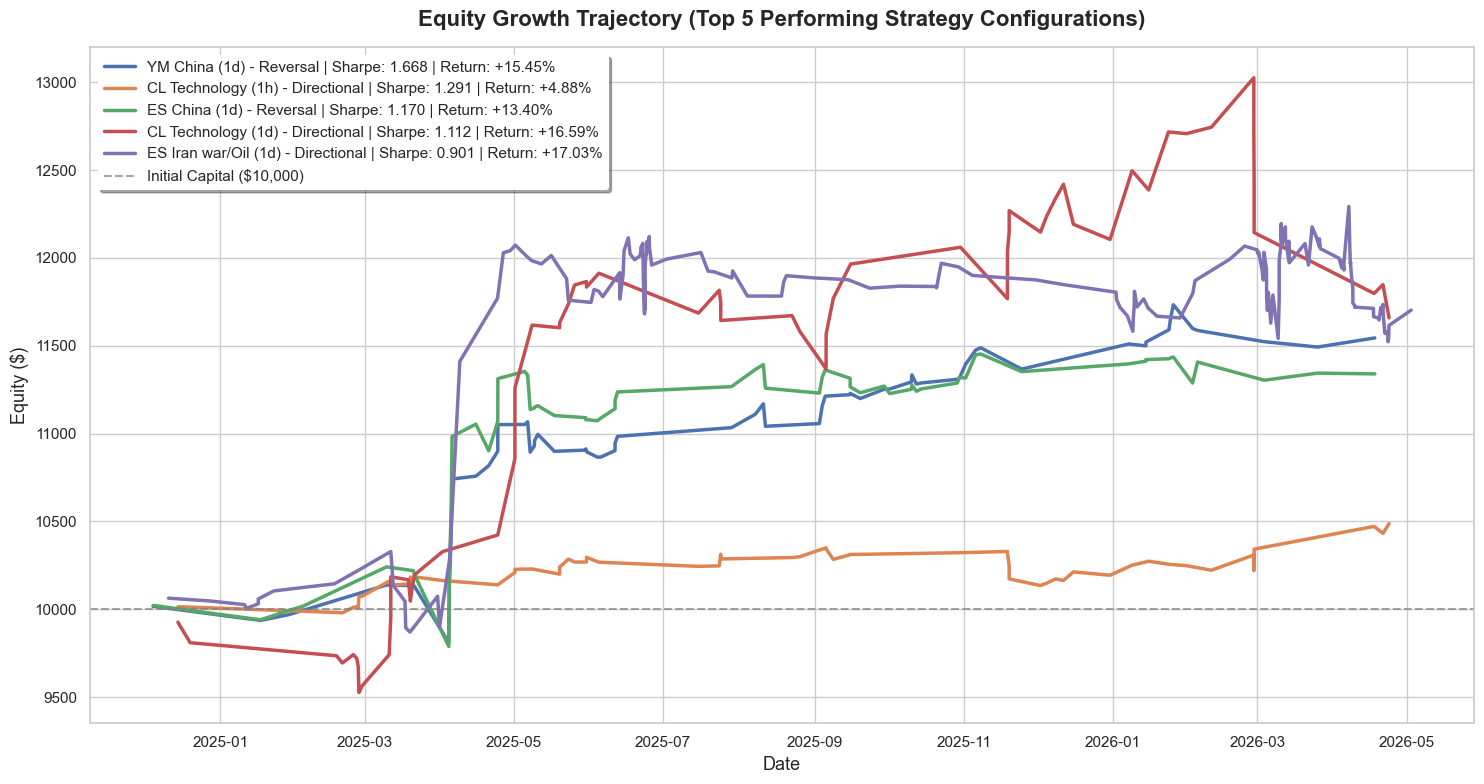

In [7]:
# Find top 5 configurations by Sharpe Ratio
top_5 = df_results.sort_values(by="Sharpe Ratio", ascending=False).head(5)

plt.figure(figsize=(15, 8))

for idx, row in top_5.iterrows():
    csv_path = row["CSV Path"]
    if os.path.exists(csv_path):
        try:
            df_trades = pd.read_csv(csv_path)
            if not df_trades.empty and 'timestamp' in df_trades.columns and 'equity' in df_trades.columns:
                df_trades["timestamp"] = pd.to_datetime(df_trades["timestamp"])
                df_trades = df_trades.sort_values(by="timestamp").reset_index(drop=True)
                
                # Construct label details
                label = f"{row['Asset']} {row['Topic']} ({row['Horizon']}) - {row['Mode']} | Sharpe: {row['Sharpe Ratio']:.3f} | Return: {row['Profit/Loss (%)']:+.2f}%"
                plt.plot(df_trades["timestamp"], df_trades["equity"], label=label, linewidth=2.5)
        except Exception as e:
            print(f"Failed to load/plot {csv_path}: {e}")

plt.title("Equity Growth Trajectory (Top 5 Performing Strategy Configurations)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Equity ($)", fontsize=13)
plt.axhline(10000.0, color='gray', linestyle='--', alpha=0.7, label="Initial Capital ($10,000)")
plt.legend(loc="upper left", frameon=True, shadow=True, facecolor="white", edgecolor="none")
plt.tight_layout()
plt.show()